**Bài tập:** Cho tập dữ liệu về bệnh ung thư: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

Trong đó là các thông tin về đặc điểm của tế bào đã được ghi nhận thành các thuộc tính (radius_mean, texture_mean, ...), thể hiện dưới dạng bảng. Cùng với đó là các chẩn đoán (diagnosis) liệu tế bào đó có phải là tế bào ung thư hay không.

Hãy xây dựng mô hình Naive Bayes để dự đoán liệu một tế bào với các đặc điểm cho trước có phải là một tế bào ung thư hay không?

* Import các thư viện cần thiết và load dữ liệu từ file

In [1]:
#Import các thư viện cần thiết
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load data 
data = pd.read_csv("cancer_data.csv")
data.head() #Quan sát dữ liệu cho thấy, tập dữ liệu đã được xử lí khá "sạch"

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [7]:
# Loại trường không cần thiết: id, unnamed
data = data.drop(["id", "Unnamed: 32"], axis = 1)

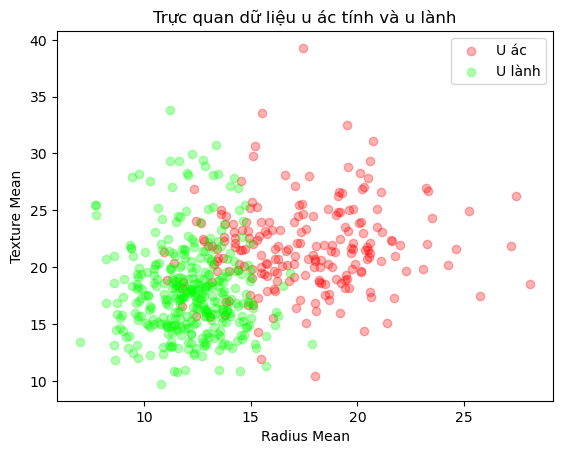

In [8]:
#Trực quan hóa về dữ liệu: u ác tính và u lành:
M = data[data.diagnosis == "M"] # dữ liệu ứng với u ác tính
B = data[data.diagnosis == "B"] # dữ liệu ứng với u lành

plt.title("Trực quan dữ liệu u ác tính và u lành")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.scatter(M.radius_mean, M.texture_mean, color = "red", label = "U ác", alpha = 0.3)
plt.scatter(B.radius_mean, B.texture_mean, color = "lime", label = "U lành", alpha = 0.3)
plt.legend()
plt.show()

* Tiền xử lí trước khi huấn luyện mô hình:

In [9]:
# Câu hỏi: Đưa trường chẩn đoán từ dạng chữ thành dạng số: M--> 1, B --> 0
# Code ###########
data.diagnosis = [1 if i == 'M' else 0 for i in data.diagnosis]
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
# Tách thuộc tính và nhãn:
X = data.drop("diagnosis", axis = 1).values 
y = data.diagnosis.values

In [11]:
# Chuẩn hóa các trường của X
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [13]:
# Câu hỏi: Chia dữ liệu train/test:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##############################

* Xây dựng và đánh giá mô hình Naive Bayes:

In [15]:
from sklearn.naive_bayes import MultinomialNB
model_MNB = MultinomialNB()
model_MNB.fit(x_train, y_train)
print("Multinormial Naive Bayes score: ", model_MNB.score(x_test, y_test))


Multinormial Naive Bayes score:  0.9385964912280702


In [16]:
# Câu hỏi: Gaussian NB:

# Code ########################################
from sklearn.naive_bayes import GaussianNB
model_GNB = GaussianNB()
model_GNB.fit(x_train, y_train)

print("Gaussian Naive Bayes score: ", model_GNB.score(x_test, y_test))

#############################################

Gaussian Naive Bayes score:  0.9736842105263158


In [19]:
# Câu hỏi: Dùng GNB để dự đoán thử một sample = phần tử đầu tiên của x_test:

test1 = model_GNB.predict(x_test[0].reshape(1, -1))
if test1 == 1:
    print("Dự đoán: U ác tính")
else:
    print("Dự đoán: U lành")


################################################

Dự đoán: U lành
